

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical Assignment 3 -      Hidden Markov Models <br>
<font color=696880 size=5>
Provided By: 
Matin Bagheri,
Mohamadreza Javadi
 

**Student Name:** Arvin Baghal Asl

**Student ID:** 403105793


# Hidden Markov Models — Robot Localization


---

# 1. Introduction

Robot localization is a fundamental problem in artificial intelligence and robotics. Since a robot cannot directly access its true position, it must estimate its location using uncertain sensor measurements and knowledge about how it moves in the environment. This uncertainty makes probabilistic modeling essential.

Hidden Markov Models (HMMs) provide a powerful framework for representing such systems. In an HMM, the robot’s actual position is treated as a hidden state, while sensor readings are considered observable variables generated probabilistically from those states. By combining transition probabilities and observation probabilities, the model can continuously update its belief about the robot’s location.

In this assignment, we explore several important inference techniques used with HMMs. A robot moves inside a building composed of multiple rooms. The robot:

- cannot directly observe its true location,
- receives noisy sensor observations,
- and must infer its hidden position over time.

This problem is a classical application of Hidden Markov Models.

Throughout this notebook, we will implement and analyze:

- Hidden Markov Models
- Filtering / Monitoring
- Forward Algorithm
- Prediction
- Online Belief Updates
- State Trellis
- Viterbi Algorithm
- Particle Filtering

---

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter


### Environment Definition

To study robot localization using Hidden Markov Models, we first define a simplified indoor environment composed of interconnected rooms. Each room represents a possible hidden state of the robot. At any moment, the robot occupies exactly one room, but its true position is not directly observable.

The environment is intentionally small and structured so that the probabilistic behavior of the robot can be analyzed clearly while still capturing the uncertainty present in real localization problems. The robot may move between neighboring rooms, and its sensors provide noisy observations related to its surroundings.

The layout of the environment is shown below:


```text
┌─────────────┬─────────────┬─────────────┬────────────────┐
│  Kitchen    │  Hallway3   │  Office2    │  Laboratory2   │
├─────────────┼─────────────┼─────────────┼────────────────┤
│  Hallway1   │  Hallway2   │  Office1    │  Laboratory1   │
└─────────────┴─────────────┴─────────────┴────────────────┘

```
Each cell corresponds to a hidden state in the Hidden Markov Model. As the robot moves through the building, transitions between these states occur according to predefined movement probabilities. Sensor readings generated in each room will later be used to infer the robot’s most likely location over time.



In [2]:
states = [
    'Kitchen',
    'Hallway1',
    'Hallway2',
    'Hallway3',
    'Office1',
    'Office2',
    'Lab1',
    'Lab2'
]

state_to_idx = {s:i for i,s in enumerate(states)}
idx_to_state = {i:s for s,i in state_to_idx.items()}
n_states = len(states)

### Observation Space

The robot cannot directly observe its true location. Instead, it receives noisy sensor readings from the environment. These observations provide partial information about where the robot might be, but they are not always accurate.

Possible observations include:

- smell_coffee
- hear_people
- hear_keyboard
- chemical_smell

For example, smelling coffee may suggest that the robot is near the kitchen, while hearing keyboards may indicate an office area. However, since observations are noisy and uncertain, the same observation may sometimes occur in different rooms. This uncertainty is what makes Hidden Markov Models useful for localization problems.



In [3]:
observations = [
    'smell_coffee',
    'hear_people',
    'hear_keyboard',
    'chemical_smell'
]

obs_to_idx = {o:i for i,o in enumerate(observations)}
idx_to_obs = {i:o for o,i in obs_to_idx.items()}
n_observations = len(observations)

### Transition Model

The transition model describes how the robot moves between rooms over time. Since the robot’s movement is not perfectly predictable, we represent it using probabilities.

The transition matrix defines

$$
P(X_t \mid X_{t-1})
$$

which represents the probability of moving to a new state at time \(t\) given the previous state at time \(t-1\).

In the matrix:

- each row represents the current room,
- each column represents the next room,
- and each value indicates the probability of that transition.

Higher probabilities are assigned to neighboring or connected rooms, while impossible movements have probability zero.


### Transition Matrix

In [4]:
transition_matrix = np.array([

# K      H1     H2     H3     O1     O2     L1     L2
[0.4,   0.3,   0.05,  0.25,  0.0,   0.0,   0.0,   0.0],   # Kitchen

[0.35,  0.35,  0.25,  0.05,  0.0,   0.0,   0.0,   0.0],   # Hallway1

[0.03,  0.2,   0.15,  0.25,  0.3,   0.07,  0.0,   0.0],   # Hallway2

[0.1,   0.02,  0.2,   0.35,  0.03,  0.3,   0.0,   0.0],   # Hallway3

[0.0,   0.0,   0.2,   0.05,  0.2,   0.2,   0.3,   0.05],  # Office1

[0.0,   0.0,   0.0,   0.2,   0.3,   0.2,   0.05,  0.25],  # Office2

[0.0,   0.0,   0.0,   0.0,   0.25,  0.1,   0.4,   0.25],  # Laboratory1

[0.0,   0.0,   0.0,   0.0,   0.1,   0.3,   0.3,   0.3]    # Laboratory2

])

The heatmap below visualizes the transition probabilities between rooms. Darker cells represent higher probabilities, showing which movements are more likely for the robot at each time step.

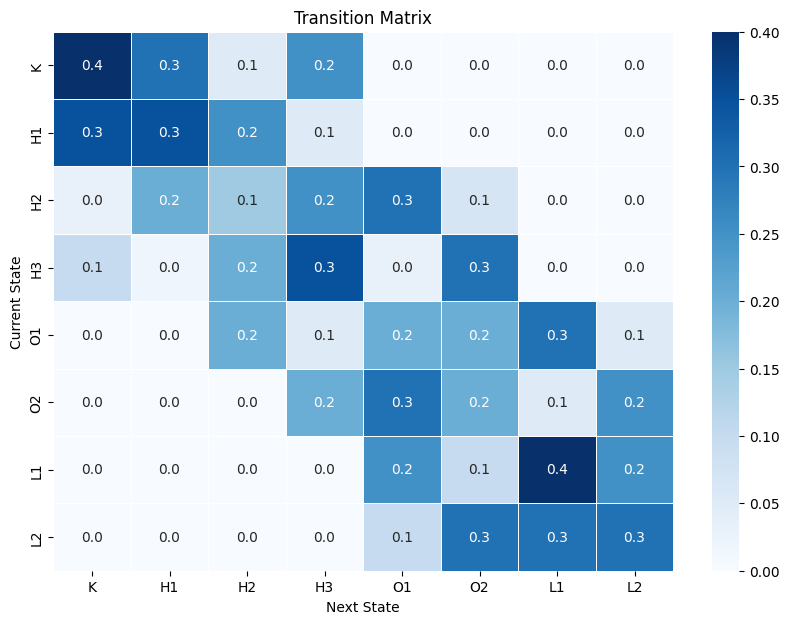

In [5]:
states_shortname = ["K", "H1", "H2", "H3", "O1", "O2", "L1", "L2"]

plt.figure(figsize=(10, 7))
sns.heatmap(
    pd.DataFrame(transition_matrix, index=states_shortname, columns=states_shortname),
    annot=True,
    cmap="Blues",
    fmt=".1f",
    linewidths=0.5
)

plt.title("Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.show()

### Emission Model

The emission model describes how likely the robot is to receive a certain observation while being in a specific room. Since the robot’s sensors are noisy, observations are probabilistic rather than perfectly reliable.

The emission matrix defines

$$
P(E_t \mid X_t)
$$

which represents the probability of observing evidence $E_t$ given the hidden state $X_t$.

In this matrix:

- each row corresponds to a room (hidden state),
- each column corresponds to a possible observation,
- and each value indicates how likely that observation is in that room.

For example, the probability of detecting `smell_coffee` is expected to be higher in the kitchen, while `chemical_smell` is more likely in laboratories.


### Emission Matrix


In [6]:
emission_matrix = np.array([
    
# coffee people keyboard chemical
[0.75, 0.20, 0.05, 0.00],   # Kitchen
[0.15, 0.80, 0.05, 0.00],   # Hallway1
[0.10, 0.75, 0.15, 0.00],   # Hallway2
[0.05, 0.80, 0.15, 0.00],   # Hallway3
[0.00, 0.10, 0.80, 0.10],   # Office1
[0.00, 0.10, 0.75, 0.15],   # Office2
[0.00, 0.05, 0.15, 0.80],   # Laboratory1
[0.00, 0.05, 0.10, 0.85]    # Laboratory2
])

The heatmap below shows the observation probabilities for each room. Darker colors indicate observations that are more likely to be detected in a specific state.

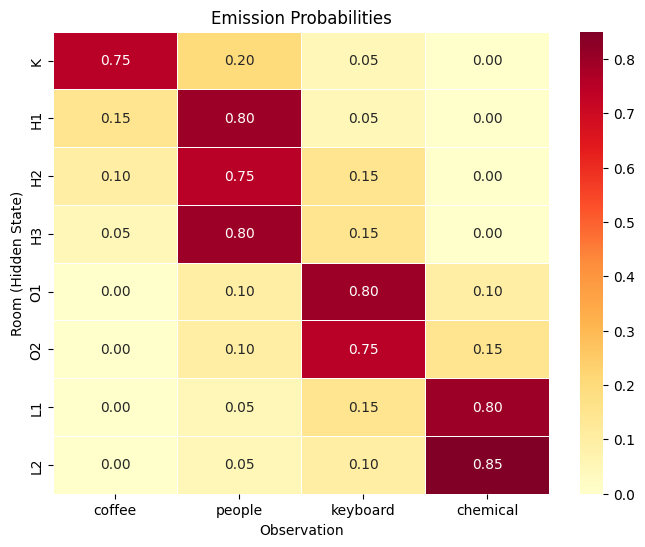

In [7]:
observations_shortname = ["coffee","people","keyboard","chemical"]

df = pd.DataFrame(emission_matrix, index=states_shortname, columns=observations_shortname)

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5)

plt.title("Emission Probabilities")
plt.xlabel("Observation")
plt.ylabel("Room (Hidden State)")
plt.show()

### Initial State Distribution


In [8]:
initial_distribution =  np.arange(n_states, 0, -1) / ((n_states+1)*n_states/2)

### Visualizing the Environment

To better understand the localization process, we create a simple visualization of the environment. Each room is displayed as a cell in a small grid, allowing us to observe the robot’s position and the probability distribution over states.

In [9]:
room_positions = {
    'Kitchen': (0, 1),
    'Hallway1': (0, 0),
    'Hallway2': (1, 0),
    'Hallway3': (1, 1),
    'Office1': (2, 0),
    'Office2': (2, 1),
    'Lab1': (3, 0),
    'Lab2': (3, 1)
}

In [10]:
def plot_environment(true_state=None, belief=None):
    
    fig, ax = plt.subplots(figsize=(6,6))
    
    for state, (x, y) in room_positions.items():
        
        prob = 0
        if belief is not None:
            prob = belief[state_to_idx[state]]
        
        color = plt.cm.Blues(prob)
        
        rect = plt.Rectangle((x, y), 1, 1, color=color, ec='black')
        ax.add_patch(rect)
        
        label = state
        
        if belief is not None:
            label += f'\n{prob:.2f}'
        
        ax.text(x+0.5, y+0.5, label,
                ha='center', va='center', fontsize=11)
    
    if true_state is not None:
        x, y = room_positions[true_state]
        ax.plot(x+0.5, y+0.5, 'ro', markersize=16)
    
    ax.set_xlim(0,4)
    ax.set_ylim(0,2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Robot Localization Environment')
    
    plt.show()

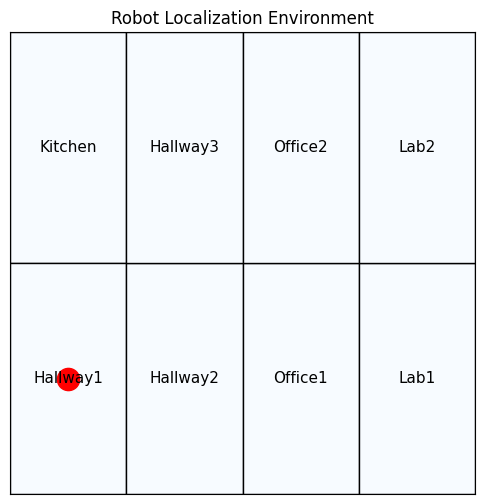

In [11]:
plot_environment(true_state='Hallway1')

### Sequence Generation

To simulate the robot localization problem, we generate sequences of hidden states and observations using the HMM parameters.

At each time step:

- the robot moves to a new room according to the transition model,
- and then produces a noisy observation based on the emission model.

This allows us to create realistic trajectories and sensor readings that can later be used to test filtering, prediction, and decoding algorithms.

#### Sampling Function


In [12]:
def sample_sequence(length=20):
	
	hidden_states = []
	observed_sequence = []
	
	# randomly choose the initial state, with regards to the initial distribution
	current_state = np.random.choice(states, p=initial_distribution)
	hidden_states.append(current_state)
	
	current_idx = state_to_idx[current_state]
	
	# randomly choose the initial observation, with regards to the emission matrix
	obs = np.random.choice(observations, p=emission_matrix[current_idx])
	observed_sequence.append(obs)
	
	for _ in range(length-1):
		# randomly choose the next state, with regards to the transition matrix
		current_state = np.random.choice(states, p=transition_matrix[current_idx])
		current_idx = state_to_idx[current_state]
		
		hidden_states.append(current_state)
		
		# randomly choose the initial observation, with regards to the emission matrix
		obs = np.random.choice(observations, p=emission_matrix[current_idx])
		
		observed_sequence.append(obs)
	
	return hidden_states, observed_sequence


### Generate Example Data


In [13]:
# generate a sample sequence of length 20
hidden_states, observed_sequence = sample_sequence(length=20)

for i, (state, obs) in enumerate(zip(hidden_states, observed_sequence)):
    print(f"{i:2d}: state = {str(state):10s} | obs = {str(obs)}")

 0: state = Hallway2   | obs = hear_people
 1: state = Hallway1   | obs = hear_people
 2: state = Hallway1   | obs = hear_people
 3: state = Kitchen    | obs = smell_coffee
 4: state = Hallway1   | obs = smell_coffee
 5: state = Hallway2   | obs = hear_people
 6: state = Hallway1   | obs = hear_people
 7: state = Hallway1   | obs = smell_coffee
 8: state = Hallway1   | obs = hear_people
 9: state = Hallway1   | obs = hear_people
10: state = Kitchen    | obs = hear_keyboard
11: state = Kitchen    | obs = smell_coffee
12: state = Hallway1   | obs = hear_people
13: state = Hallway2   | obs = hear_keyboard
14: state = Hallway1   | obs = hear_people
15: state = Hallway1   | obs = smell_coffee
16: state = Hallway2   | obs = hear_people
17: state = Office1    | obs = hear_keyboard
18: state = Office2    | obs = hear_keyboard
19: state = Hallway3   | obs = hear_people


---
# 2. Forward Algorithm

The Forward Algorithm is used to update the robot’s belief about its current location as new observations arrive. Since the true state is hidden, the algorithm maintains a probability distribution over all possible states.

At each time step, the belief is updated using two steps:

- **Prediction:** estimate the next state using the transition model.
- **Update:** incorporate the new observation using the emission model.

This process computes the filtering distribution

$$
P(X_t \mid e_{1:t})
$$

which represents the probability of the robot being in each state after observing the evidence up to time $t$.


###  Belief Initialization


In [14]:
belief = initial_distribution.copy()
print(belief)

[0.22222222 0.19444444 0.16666667 0.13888889 0.11111111 0.08333333
 0.05555556 0.02777778]


### Observation Update

After receiving a new observation \(e_t\), the robot updates its belief about the current state. This step incorporates the likelihood of the observation given each possible hidden state.

Mathematically, we compute

$$
P(X_t \mid e_t)
$$

by weighting the current belief with the emission probabilities corresponding to the observed evidence, followed by normalization so that the probabilities sum to 1.

This update allows the robot to adjust its belief distribution according to the new sensor information.



In [15]:
def observation_update(belief, observation):
    
    updated_belief = np.zeros(n_states)
    
    obs_idx = obs_to_idx[observation]
    
    for s in range(n_states):
        # Multiply prior belief by emission probability
        updated_belief[s] = belief[s] * emission_matrix[s, obs_idx]
    
    # Normalize probabilities
    updated_belief /= sum(updated_belief)
    
    return updated_belief

### Time Elapse Update

The time elapse update predicts how the belief state changes after the robot moves to the next time step. Instead of using observations, this step relies only on the transition model.

The updated belief is computed by propagating the current probabilities through the transition matrix, producing a prediction of the robot’s next possible locations.

This step represents the prediction phase of the Forward Algorithm.


In [16]:
def time_update(belief):
    
    predicted_belief = np.zeros(n_states)
    
    for next_state in range(n_states):
        
        total = 0
        
        for current_state in range(n_states):
            # compute next-state belief using transition probabilities
            total += belief[current_state] * transition_matrix[current_state, next_state]
            
        # assign proper value
        predicted_belief[next_state] = total
    
    return predicted_belief

### Complete Forward Step


In [17]:
def forward_step(belief, observation):
    
    # use the functions above
    predicted = time_update(belief)
    updated = observation_update(predicted, observation)
    
    return updated

### Online Belief Updates

We now update the robot belief sequentially.


In [18]:
belief = initial_distribution.copy()

belief_history = []

for obs in observed_sequence:
    # Update belief using forward_step
    belief = forward_step(belief, obs)
    
    belief_history.append(belief.copy())

### Belief Evolution Visualization

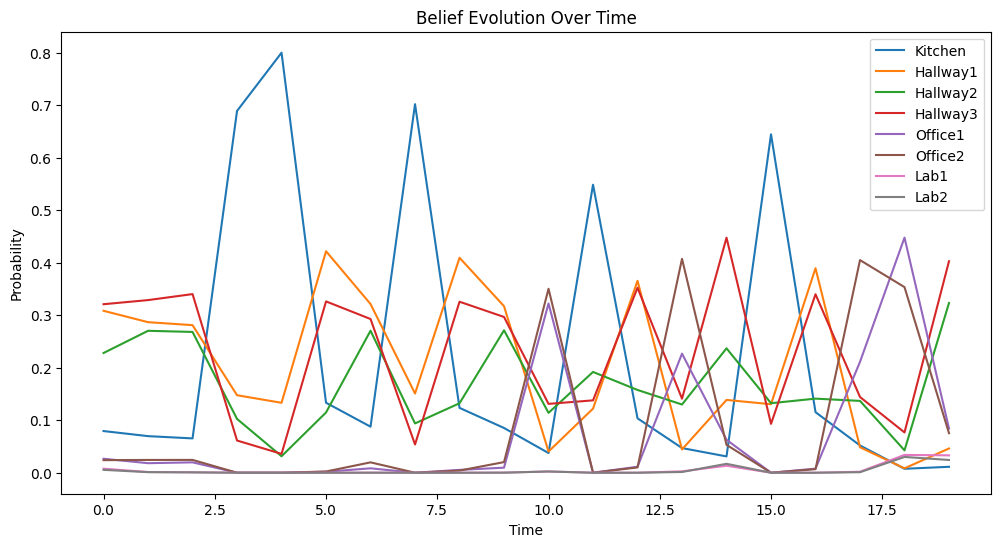

In [19]:
belief_history = np.array(belief_history)

plt.figure(figsize=(12,6))

for i, state in enumerate(states):
    plt.plot(belief_history[:,i], label=state)

plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Belief Evolution Over Time')
plt.legend()
plt.show()

### Prediction

Prediction estimates future hidden states **without receiving new observations**. Instead of incorporating sensor evidence, the belief distribution is projected forward in time using only the transition model.

Starting from the current belief \(P(X_t)\), the predicted distribution for the next step is computed as

$$
P(X_{t+1}) = \sum_{x_t} P(X_{t+1} \mid x_t)\, P(x_t)
$$

This process can be repeated multiple times to estimate the robot’s probable locations several steps into the future. As the prediction horizon increases, the belief distribution gradually spreads according to the movement dynamics defined in the transition matrix.

Prediction is useful for anticipating where the robot might be in the future when no new sensor information is available.


In [20]:
def predict_future(belief, steps=5):
    
    predictions = []
    current = belief.copy()
    
    for _ in range(steps):
        # Apply time update
        current = time_update(belief=current)

        predictions.append(current.copy())
    
    return np.array(predictions)

---
# 3. Viterbi Algorithm

The Viterbi algorithm computes the most likely sequence of hidden states that could have generated a sequence of observations.

Unlike filtering, which estimates the current state distribution, Viterbi searches for the single most probable path through the hidden states over time.

Given observations

$$
e_{1:T}
$$

the algorithm finds

$$
\arg\max_{x_{1:T}} P(x_{1:T} \mid e_{1:T})
$$

The algorithm uses dynamic programming to efficiently compute this sequence by storing intermediate best-path probabilities inside a structure called a trellis.

Viterbi is widely used in robot localization, speech recognition, bioinformatics, and many other sequential inference problems.

## Trellis Initialization

The first step of the Viterbi algorithm initializes the trellis using the initial belief distribution and the likelihood of the first observation.

For each state \(x_i\), we compute

$$
V_1(x_i) = P(x_i)\, P(e_1 \mid x_i)
$$

where:

- $P(x_i)$ is the initial probability of starting in state $x_i$
- $P(e_1 \mid x_i)$ is the emission probability of the first observation

The resulting values represent the probability of the most likely path ending in each state at time step $1$.


In [21]:
def viterbi(observed_sequence):
    
    T = len(observed_sequence)
    
    delta = np.zeros((T, n_states))
    psi = np.zeros((T, n_states), dtype=int)

    # Initialization
    first_obs = obs_to_idx[observed_sequence[0]]
    
    for s in range(n_states):
        # Initialize delta values
        delta[0, s] = (
			initial_distribution[s] * emission_matrix[s, first_obs]
        )

    # Recursion
    for t in range(1, T):
        
        # get current observation idx 
        obs_idx = obs_to_idx[observed_sequence[t]]
        
        for s in range(n_states):
            
            candidates = []
            
            for prev_s in range(n_states):
                
                # calculate the probability using transition matrix
                candidates.append(
                    delta[t-1, prev_s] * transition_matrix[prev_s, s]
                )
            
            psi[t, s] = np.argmax(candidates)
            
            # Compute delta[t, s]
            delta[t, s] = (
                candidates[psi[t, s]] * emission_matrix[s, obs_idx]
            )

    # Backtracking
    path = np.zeros(T, dtype=int)

    # Find final state
    path[T - 1] = np.argmax(delta[T - 1])

    for t in range(T - 2, -1, -1):
        # Backtrack
        path[t] = psi[t+1, path[t+1]]

    # convert idx to state
    decoded_states = [idx_to_state[i] for i in path]
    
    return decoded_states

In [22]:
predicted_states = viterbi(observed_sequence)

#### Compare True vs Predicted States


In [23]:
comparison_df = pd.DataFrame({
    'True State': hidden_states,
    'Observation': observed_sequence,
    'Predicted State': predicted_states
})
# note that for simplicity, we only check for the general state
comparison_df['Correctness'] = (
    comparison_df['True State'].str[:-1] == comparison_df['Predicted State'].str[:-1]
)

comparison_df

,True State,Observation,Predicted State,Correctness
0,Hallway2,hear_people,Hallway1,True
1,Hallway1,hear_people,Hallway1,True
2,Hallway1,hear_people,Hallway1,True
3,Kitchen,smell_coffee,Kitchen,True
4,Hallway1,smell_coffee,Kitchen,False
5,Hallway2,hear_people,Hallway1,True
6,Hallway1,hear_people,Hallway1,True
7,Hallway1,smell_coffee,Kitchen,False
8,Hallway1,hear_people,Hallway1,True
9,Hallway1,hear_people,Hallway1,True


---
# 4. Particle Filtering

Particle filtering approximates belief distributions using a finite set of samples called particles. Each particle represents a possible hidden state of the robot.

Instead of maintaining the full probability distribution over all states, particle filtering tracks only a collection of sampled hypotheses. This makes the method efficient for large or continuous state spaces where exact inference becomes computationally expensive.

At each time step, the algorithm performs three main operations:

1. Prediction:
   Each particle is propagated according to the transition model

   $$
   P(X_t \mid X_{t-1})
   $$

2. Weighting:
   After receiving an observation $e_t$, each particle receives a weight based on the likelihood

   $$
   P(e_t \mid X_t)
   $$

3. Resampling:
   Particles with higher weights are sampled more frequently, while unlikely particles are discarded.

As the number of particles increases, the particle approximation becomes closer to the true belief distribution.

Particle filtering is widely used in robotics because it can efficiently handle uncertainty, noisy sensors, and complex environments.


---
### Initialize Particles

In [24]:
def initialize_particles(num_particles=500):
    
    # use n_states and initial distribution
    particles = np.random.choice(n_states, size=num_particles, p=initial_distribution)
    return particles


### Particle Propagation


In [25]:
def propagate_particles(particles):
    
    new_particles = []
    
    for particle in particles:
       
        # Sample next state using transition model
        next_state = np.random.choice(n_states, p=transition_matrix[particle])
        
        new_particles.append(next_state)

    return np.array(new_particles)

### Particle Weighting


In [26]:
def compute_weights(particles, observation):
    
    weights = []
    
    obs_idx = obs_to_idx[observation]
    
    for particle in particles:
        # Compute emission likelihood
        weights.append(emission_matrix[particle, obs_idx])
    
    weights = np.array(weights)
    
    # Normalize weights
    weights /= sum(weights)

    return weights


### Resampling

In [27]:
def resample_particles(particles, weights):
    
    # resample particles based on their weights
    indices = np.random.choice(len(particles), size=len(particles), p=weights)
    
    return particles[indices]

### Estimate Belief From Particles


In [28]:
def particles_to_belief(particles):
    belief = np.zeros(n_states)
    counts = Counter(particles)
    
    for state, count in counts.items():
        # compute belief based on count of particles
        belief[state] = count / len(particles)
    
    return belief

### Complete Particle Filtering Loop


In [29]:
particles = initialize_particles()

particle_beliefs = []

for obs in observed_sequence:
    # Propagate particles
    particles = propagate_particles(particles)

    # Compute weights
    weights = compute_weights(particles, obs)

    # Resample particles
    particles = resample_particles(particles, weights)

    # Convert particles to belief distribution
    belief = particles_to_belief(particles)

    particle_beliefs.append(belief)


### Particle Belief Visualization

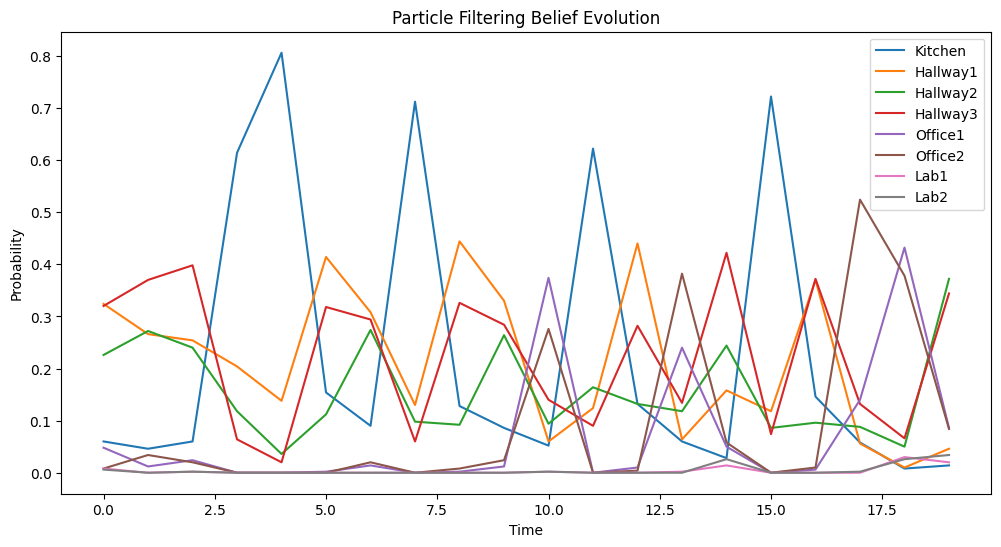

In [30]:
particle_beliefs = np.array(particle_beliefs)

plt.figure(figsize=(12,6))
for i, state in enumerate(states):
    plt.plot(particle_beliefs[:, i], label=state)

plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Particle Filtering Belief Evolution')
plt.legend()
plt.show()


#### Comparing Exact Filtering vs Particle Filtering

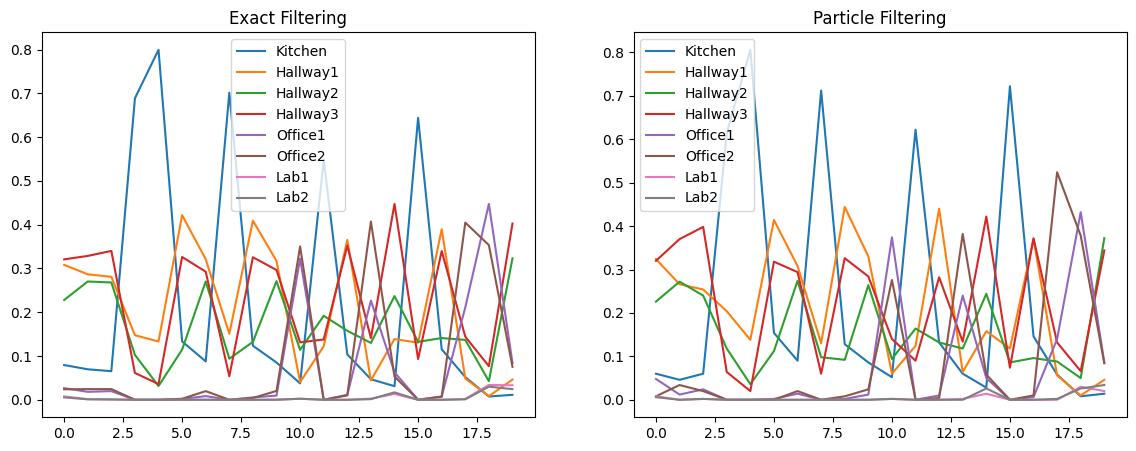

In [31]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

for i, state in enumerate(states):
    axes[0].plot(belief_history[:,i], label=state)

axes[0].set_title('Exact Filtering')
axes[0].legend()

for i, state in enumerate(states):
    axes[1].plot(particle_beliefs[:,i], label=state)

axes[1].set_title('Particle Filtering')
axes[1].legend()

plt.show()

In [32]:
# Convert particle beliefs to predicted states
particle_predicted_states = [
    idx_to_state[np.argmax(belief)]
    for belief in particle_beliefs
]

comparison_df = pd.DataFrame({
    'True State': hidden_states,
    'Observation': observed_sequence,
    'Viterbi Prediction': predicted_states,
    'ParticleFiltering Prediction': particle_predicted_states
})

comparison_df

,True State,Observation,Viterbi Prediction,ParticleFiltering Prediction
0,Hallway2,hear_people,Hallway1,Hallway1
1,Hallway1,hear_people,Hallway1,Hallway3
2,Hallway1,hear_people,Hallway1,Hallway3
3,Kitchen,smell_coffee,Kitchen,Kitchen
4,Hallway1,smell_coffee,Kitchen,Kitchen
5,Hallway2,hear_people,Hallway1,Hallway1
6,Hallway1,hear_people,Hallway1,Hallway1
7,Hallway1,smell_coffee,Kitchen,Kitchen
8,Hallway1,hear_people,Hallway1,Hallway1
9,Hallway1,hear_people,Hallway1,Hallway1


---
# 5. Discussion Questions

\# TODO: answer questions below

#### Question 1

Why is particle filtering considered an approximate inference algorithm?  
In what case would particle filtering be equivalent to exact filtering?

Answer: Particle filtering is called "approximate" because it **relies on a smart guessing game instead of doing exact, heavy math for every single room**. Instead of calculating perfect percentages, it just scatters a bunch of random "clone" robots on the map and counts where they cluster to get a rough idea of where the real robot is. It’s an amazing shortcut, but it's not mathematically flawless. The only time this guessing game becomes exactly equivalent to perfect math is if you use an **infinite number of particles**. With infinity particles, the random luck of the dice rolls smooths out completely, and the particle clusters line up perfectly with the exact mathematical truth.

#### Question 2
What happens when the number of particles is very small?  
Describe how this affects the quality of the belief approximation.

Answer: If particle count drops too low, our tracking falls into a dangerous trap. Because we only have a tiny handful of guesses on the board, **a single unlucky step or a weird sensor reading can easily kill off the only particles that actually knew where the robot was**. When that happens, remaining particles all get sucked into the wrong room. Our belief approximation completely breaks down: **the robot becomes overwhelmingly confident about a total lie and gets permanently lost**.

---


## Conclusion

In this notebook, we implemented:

- Hidden Markov Models  
- Filtering  
- Forward Algorithm  
- Prediction  
- Online Belief Updates  
- State Trellis  
- Viterbi Algorithm  
- Particle Filtering  

using a robot localization problem.

This assignment demonstrates how probabilistic sequential models can infer hidden states from noisy observations, combine prior knowledge with evidence, and reason about uncertainty over time in a principled mathematical framework.

---
